# Tutorial: body-fitted 2D centered-vug upscaling

This notebook is for a researcher who is new to `voids` and wants to generate
a controlled family of centered circular vugs and compare two single-phase
continuum models:

- Darcy--Brinkman;
- Darcy--Darcy with residual-based variational multiscale (VMS)
  stabilization.

Both use Taylor--Hood $[\mathrm{P}_2]^2/\mathrm{P}_1$ velocity/pressure
fields on the same type of body-fitted Gmsh mesh. By the end, you will be able
to configure the geometry and material properties, solve every case, inspect
pressure and velocity fields, compute $K_\mathrm{eff}/K_\mathrm{rock}$, run
a mesh-sensitivity check, and open exported fields in ParaView.

## 1. What is being modeled?

The physical square corresponds to a hypothetical $500^2$-pixel image with
$15\,\mu\mathrm{m}$ pixels:

$$
L=500(15\,\mu\mathrm{m})=7.5\,\mathrm{mm}.
$$

The image dimensions supply physical provenance only. We do **not** solve on
250,000 square pixels. Gmsh creates a nearly uniform triangular continuum
mesh, fitted exactly to the circular matrix--vug interface, with a nominal
resolution equivalent to about $100\times100$ cells.

The matrix is a porous continuum, not an impermeable solid:

$$
\phi_m=0.2,\qquad K_m=200\,\mathrm{mD}.
$$

The centered circle occupies the requested total-domain area fraction

$$
f_v=\frac{A_v}{A_T},\qquad
r=L\sqrt{\frac{f_v}{\pi}}.
$$

A contained circle can reach at most $\pi/4\approx0.7854$, so every requested
value through 0.70 is geometrically admissible. At 0.70, the circle leaves
about $0.21\,\mathrm{mm}$, or 14 pixels, between itself and each square side.

## 2. Governing models and the vug "permeability"

Let $\Omega=\Omega_m\cup\Omega_v$ be the matrix/vug partition. Following the
layered-domain model, define the Darcy--Brinkman reaction coefficient by

$$
\gamma_B(\mathbf x)=
\begin{cases}
\mu/K_m,&\mathbf x\in\Omega_m,\\
0,&\mathbf x\in\Omega_v.
\end{cases}
$$

The Darcy--Brinkman strong equations are

$$
-\nabla\!\cdot(\nu_\mathrm{eff}\nabla\mathbf u)
+\gamma_B\mathbf u+\nabla p=0,
\qquad \nabla\!\cdot\mathbf u=0,
$$

with

$$
\nu_\mathrm{eff}=
\begin{cases}
\mu/\phi_m,&\text{matrix},\\
\mu,&\text{vug}.
\end{cases}
$$

Denote the left inlet, right outlet, and impermeable top/bottom walls by
$\Gamma_L$, $\Gamma_R$, and
$\Gamma_W=\Gamma_T\cup\Gamma_B$, respectively. The pressure data are

$$
p_L=1\,\mathrm{Pa},\qquad p_R=0\,\mathrm{Pa},\qquad
\Delta p=p_L-p_R=1\,\mathrm{Pa}.
$$

Both models impose wall impermeability,

$$
\mathbf u\!\cdot\mathbf n=0\qquad\text{on }\Gamma_W.
$$

For Darcy--Brinkman, the left/right pressure-traction conditions are

$$
(\nu_\mathrm{eff}\nabla\mathbf u-p\mathbf I)\mathbf n
=-p_L\mathbf n\quad\text{on }\Gamma_L,\qquad
(\nu_\mathrm{eff}\nabla\mathbf u-p\mathbf I)\mathbf n
=-p_R\mathbf n\quad\text{on }\Gamma_R.
$$

Because only the normal velocity is constrained on $\Gamma_W$, the
tangential Brinkman traction is natural:

$$
(\mathbf I-\mathbf n\otimes\mathbf n)
(\nu_\mathrm{eff}\nabla\mathbf u)\mathbf n=\mathbf0
\qquad\text{on }\Gamma_W.
$$

Darcy--Darcy has no viscous traction. Its pressure traces are prescribed
naturally as $p=p_L$ on $\Gamma_L$ and $p=p_R$ on $\Gamma_R$, with the same
zero-normal-velocity wall condition. No strong pressure Dirichlet degrees of
freedom are imposed in either discrete system.

The matrix--vug curve is an internal material interface, not an exterior
boundary. The single-domain conforming discretization makes velocity and
pressure single-valued across it. For Darcy--Brinkman, traction balance across
that interface follows from the weak form because no singular interface load
is added. This continuous-pressure choice is part of the requested P2/P1
formulation.

Define

$$
V=\{\mathbf v\in[H^1(\Omega)]^2:
v_y=0\text{ on }\Gamma_W\},\qquad Q=H^1(\Omega).
$$

Both discrete methods use the requested Taylor--Hood spaces

$$
V_h=[\mathrm{CG}_2]^2\cap V,\qquad Q_h=\mathrm{CG}_1\cap Q.
$$

### Darcy--Brinkman variational formulation

Find $(\mathbf u_h,p_h)\in V_h\times Q_h$ such that, for every
$(\mathbf v_h,q_h)\in V_h\times Q_h$,

$$
\begin{aligned}
&(\nu_\mathrm{eff}\nabla\mathbf u_h,\nabla\mathbf v_h)_\Omega
+(\gamma_B\mathbf u_h,\mathbf v_h)_\Omega
-(p_h,\nabla\!\cdot\mathbf v_h)_\Omega
+(q_h,\nabla\!\cdot\mathbf u_h)_\Omega\\
&\qquad=\mathcal L(\mathbf v_h).
\end{aligned}
$$

### Darcy--Darcy VMS variational formulation

Darcy--Darcy omits viscous diffusion. It needs a finite drag in both regions,
so the configurable high-permeability closure is used only in this branch:

$$
\gamma_D(\mathbf x)=
\begin{cases}
\mu/K_m,&\mathbf x\in\Omega_m,\\
\mu/K_v,&\mathbf x\in\Omega_v.
\end{cases}
$$

Find
$(\mathbf u_h,p_h)\in V_h\times Q_h$ such that

$$
\begin{aligned}
&(\gamma_D\mathbf u_h,\mathbf v_h)_\Omega
-(p_h,\nabla\!\cdot\mathbf v_h)_\Omega
+(q_h,\nabla\!\cdot\mathbf u_h)_\Omega\\
&\quad+\frac12\left(
-\gamma_D\mathbf v_h+\nabla q_h,\,
\tau_M(\gamma_D\mathbf u_h+\nabla p_h)
\right)_\Omega
=\mathcal L(\mathbf v_h),
\end{aligned}
$$

where the VMS stabilization parameter is

$$
\tau_M=\min\!\left(\frac{C_Mh^2}{\mu},\frac{C_M}{\gamma_D}\right),
\qquad C_M=1.
$$

The common pressure-traction load is

$$
\mathcal L(\mathbf v_h)=
-\int_{\Gamma_L}p_L\,\mathbf v_h\!\cdot\mathbf n\,ds
-\int_{\Gamma_R}p_R\,\mathbf v_h\!\cdot\mathbf n\,ds.
$$

`voids` assembles dimensionally equivalent nondimensional forms using the
matrix Darcy velocity scale, then converts velocity, pressure, flow rate, and
permeability back to SI units.

`darcy_darcy_vug_permeability_m2 = 1e-8` is a configurable finite
high-permeability closure used **only by Darcy--Darcy**. An open cavity has no
intrinsic Darcy permeability, so this value must be reported as a modeling
parameter rather than interpreted as a measured rock property.
Darcy--Brinkman does not use this parameter in the vug: it sets
$\gamma_B=0$ there exactly.

Boundary conditions follow the layered Darcy presentation:

- natural pressure traction at left/right;
- zero normal velocity ($u_y=0$) at top/bottom;
- natural tangential traction at top/bottom.

Returned pressure is shifted to zero domain mean after solving; pressure
differences are unchanged.

Scientific basis:

- Golfier, Lasseux, and Quintard (2015),
  [DOI 10.1007/s10596-014-9448-5](https://doi.org/10.1007/s10596-014-9448-5),
  for single-domain Darcy--Brinkman effective-permeability upscaling of
  cavity/vuggy media;
- Masud (2007),
  [DOI 10.1002/fld.1508](https://doi.org/10.1002/fld.1508), for the stabilized
  mixed Darcy--Stokes formulation.

In [1]:
from __future__ import annotations

import json
from dataclasses import replace

import matplotlib

try:
    from IPython import get_ipython

    interactive_shell = get_ipython()
except ImportError:  # pragma: no cover - script fallback
    interactive_shell = None

if interactive_shell is None:
    matplotlib.use("Agg")
else:
    interactive_shell.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm, Normalize
from matplotlib.patches import Circle

try:
    from IPython.display import display
except ImportError:  # pragma: no cover - notebook convenience fallback
    display = print

from voids.examples.mms import (
    CenteredVugFlowCase2D,
    make_body_fitted_centered_vug_mesh,
    run_centered_vug_flow_case,
)
from voids.fem.singlephase import FEniCSSolverOptions
from voids.paths import notebooks_path
from voids.visualization import (
    sample_dolfinx_function_at_points,
    sample_dolfinx_function_on_grid,
    vector_magnitude,
    write_fem_result_xdmf,
)

plt.ioff()

## 3. One editable configuration cell

These are the parameters a user is expected to change:

- `image_shape` and `voxel_size_um`: physical sample size;
- `matrix_porosity` and `matrix_permeability_md`: porous-matrix model;
- `darcy_darcy_vug_permeability_m2`: finite vug closure used only by
  Darcy--Darcy; Darcy--Brinkman always uses zero vug drag;
- `dynamic_viscosity_pa_s`: fluid viscosity;
- `pressure_inlet_pa` and `pressure_outlet_pa`: applied pressure traction;
- `vug_area_fractions`: circle fractions to generate;
- `mesh_resolution`: nominal near-regular Gmsh resolution;
- `plot_sample_resolution`: regular sampling used only for Matplotlib, not for
  the FEM solve;
- `centerline_sample_count`: exact FEM evaluations along $y/L=0.5$.

The equations are linear, so changing the pressure drop rescales velocity but
should not change the reported permeability, up to algebraic error.

In [2]:
image_shape = (500, 500)
voxel_size_um = 15.0
matrix_porosity = 0.2
matrix_permeability_md = 200.0
darcy_darcy_vug_permeability_m2 = 1.0e-8
dynamic_viscosity_pa_s = 1.0e-3
pressure_inlet_pa = 1.0
pressure_outlet_pa = 0.0

vug_area_fractions = (0.0, 0.01, 0.05, 0.10, 0.20, 0.40, 0.60, 0.70)
mesh_resolution = 100
plot_sample_resolution = 160
centerline_sample_count = 401
vms_constant = 1.0

# SuperLU is available through SciPy and keeps the tutorial portable. The
# package also exposes PETSc/MUMPS and UMFPACK options for larger studies.
solver_options = FEniCSSolverOptions.superlu_direct()

output_dir = (
    notebooks_path() / "outputs" / "53_mwe_body_fitted_2d_centered_vug_upscaling"
)
paraview_dir = output_dir / "paraview"
field_figure_dir = output_dir / "field_figures"
paraview_dir.mkdir(parents=True, exist_ok=True)
field_figure_dir.mkdir(parents=True, exist_ok=True)

## 4. Build and inspect the case family

`CenteredVugFlowCase2D` performs unit conversion and validation. In
particular, it converts mD to $\mathrm{m}^2$, derives the physical side
length and radius, and rejects a circle that would cross the square boundary.

In [3]:
common_parameters = {
    "image_shape": image_shape,
    "voxel_size_m": voxel_size_um * 1.0e-6,
    "matrix_porosity": matrix_porosity,
    "matrix_permeability_md": matrix_permeability_md,
    "vug_permeability_m2": darcy_darcy_vug_permeability_m2,
    "dynamic_viscosity_pa_s": dynamic_viscosity_pa_s,
    "pressure_inlet_pa": pressure_inlet_pa,
    "pressure_outlet_pa": pressure_outlet_pa,
    "mesh_resolution": mesh_resolution,
}
cases = [
    CenteredVugFlowCase2D(area_fraction=fraction, **common_parameters)
    for fraction in vug_area_fractions
]

case_table = pd.DataFrame(
    [
        {
            "vug area fraction": case.area_fraction,
            "radius [mm]": 1.0e3 * case.radius_m,
            "edge gap [mm]": 1.0e3 * (0.5 * case.side_length_m - case.radius_m),
            "side [mm]": 1.0e3 * case.side_length_m,
            "Krock [m2]": case.matrix_permeability_m2,
            "Kvug,DD/Krock": case.permeability_contrast,
            "target h [um]": (
                1.0e6 * case.base_target_mesh_size_fraction * case.side_length_m
            ),
        }
        for case in cases
    ]
)
display(case_table)

assert cases[0].radius_m == 0.0
assert all(case.radius_m < 0.5 * case.side_length_m for case in cases[1:])
assert np.all(np.diff([case.radius_m for case in cases]) > 0.0)

,vug area fraction,radius [mm],edge gap [mm],side [mm],Krock [m2],"Kvug,DD/Krock",target h [um]
0,0.00,0.000000,3.750000,7.5,1.973847e-13,50662.498291,106.066017
1,0.01,0.423142,3.326858,7.5,1.973847e-13,50662.498291,106.066017
2,0.05,0.946175,2.803825,7.5,1.973847e-13,50662.498291,106.066017
3,0.10,1.338093,2.411907,7.5,1.973847e-13,50662.498291,106.066017
4,0.20,1.892349,1.857651,7.5,1.973847e-13,50662.498291,106.066017
5,0.40,2.676186,1.073814,7.5,1.973847e-13,50662.498291,106.066017
6,0.60,3.277645,0.472355,7.5,1.973847e-13,50662.498291,106.066017
7,0.70,3.540262,0.209738,7.5,1.973847e-13,50662.498291,106.066017


The bulk geometric void fraction is not just $f_v$. If the vug is completely
void and the matrix porosity remains $\phi_m$, a simple area-weighted
geometric estimate is

$$
\phi_\mathrm{bulk}=f_v+(1-f_v)\phi_m.
$$

This quantity is useful bookkeeping, but it is not used as a replacement for
the piecewise coefficients in either FEM model.

In [4]:
case_table["bulk porosity estimate"] = [
    case.area_fraction + (1.0 - case.area_fraction) * case.matrix_porosity
    for case in cases
]
display(case_table[["vug area fraction", "bulk porosity estimate"]])

,vug area fraction,bulk porosity estimate
0,0.00,0.200
1,0.01,0.208
2,0.05,0.240
3,0.10,0.280
4,0.20,0.360
5,0.40,0.520
6,0.60,0.680
7,0.70,0.760


## 5. Plot the requested geometries

The $f_v=0$ row is matrix only. Every other row contains one centered circle.

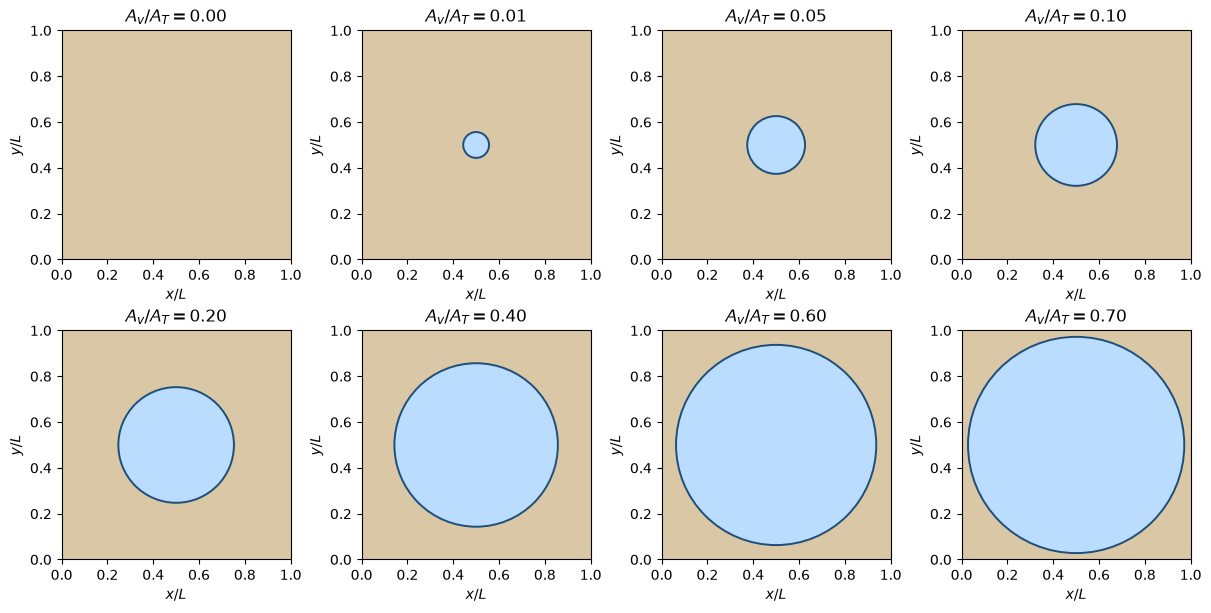

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6), constrained_layout=True)
for axis, case in zip(axes.flat, cases, strict=True):
    axis.add_patch(plt.Rectangle((0.0, 0.0), 1.0, 1.0, color="#d9c7a5"))
    if case.radius_fraction > 0.0:
        axis.add_patch(
            Circle(
                (0.5, 0.5),
                case.radius_fraction,
                facecolor="#b9dcff",
                edgecolor="#1f4e79",
                linewidth=1.4,
            )
        )
    axis.set(
        xlim=(0.0, 1.0),
        ylim=(0.0, 1.0),
        aspect="equal",
        title=rf"$A_v/A_T={case.area_fraction:.2f}$",
        xlabel=r"$x/L$",
        ylabel=r"$y/L$",
    )
geometry_figure_path = output_dir / "centered_vug_geometry_family.png"
fig.savefig(geometry_figure_path, dpi=180)
display(fig)
plt.close(fig)

## 6. Inspect a body-fitted mesh

Gmsh fragments the square with the circle and preserves separate physical tags
for matrix, vug, outer boundaries, and the internal interface. The target
diameter is $\sqrt{2}/100$ in normalized coordinates. The actual unstructured
triangle count is not exactly $2(100)^2$, and it changes slightly with the
circle.

Info    : Clearing all models and views...
Info    : Done clearing all models and views


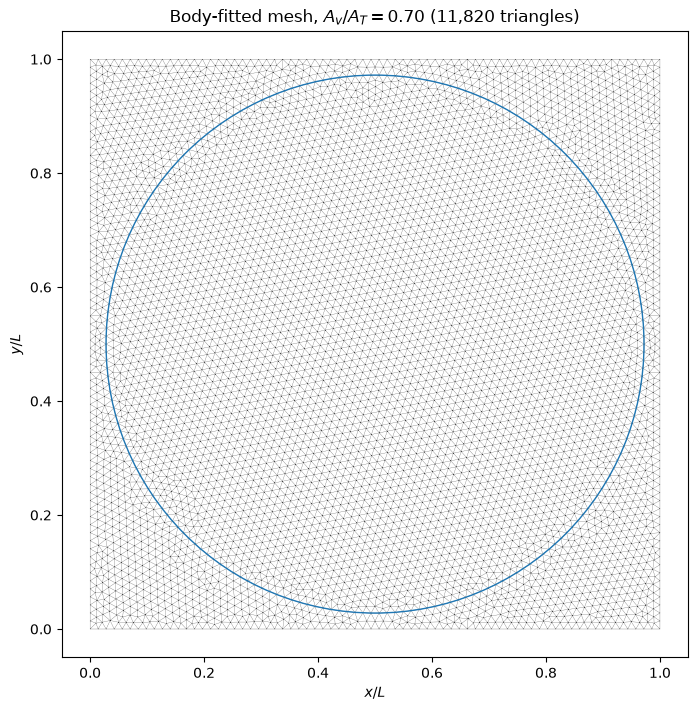

Physical groups: ['matrix', 'vug', 'vug_interface', 'x_max', 'x_min', 'y_max', 'y_min']
Cell tags: [1, 2]
Facet tags: [1, 2, 3, 4, 7]


In [6]:
mesh_case = cases[-1]
tagged_mesh = make_body_fitted_centered_vug_mesh(mesh_case.make_benchmark())
mesh = tagged_mesh.mesh
mesh.topology.create_connectivity(mesh.topology.dim, 0)
cell_vertices = mesh.topology.connectivity(mesh.topology.dim, 0)
assert cell_vertices is not None
triangles = cell_vertices.array.reshape((-1, 3))
coordinates = np.asarray(mesh.geometry.x[:, :2], dtype=float)

fig, axis = plt.subplots(figsize=(7, 7), constrained_layout=True)
axis.triplot(
    coordinates[:, 0], coordinates[:, 1], triangles, linewidth=0.18, color="0.25"
)
axis.add_patch(
    Circle(
        (0.5, 0.5),
        mesh_case.radius_fraction,
        fill=False,
        edgecolor="tab:blue",
        linewidth=1.0,
    )
)
axis.set(
    aspect="equal",
    xlabel=r"$x/L$",
    ylabel=r"$y/L$",
    title=(
        f"Body-fitted mesh, $A_v/A_T={mesh_case.area_fraction:.2f}$ "
        f"({triangles.shape[0]:,} triangles)"
    ),
)
mesh_figure_path = output_dir / "body_fitted_mesh_fraction_0p70.png"
fig.savefig(mesh_figure_path, dpi=220)
display(fig)
plt.close(fig)

print("Physical groups:", sorted(tagged_mesh.physical_groups))
print("Cell tags:", sorted(set(tagged_mesh.cell_tags.values.tolist())))
print("Facet tags:", sorted(set(tagged_mesh.facet_tags.values.tolist())))

## 7. Solve every case with both P2/P1 formulations

For each solve we also:

1. export one `.xdmf` plus its `.h5` data file for ParaView;
2. sample the FEM fields on a regular plotting grid;
3. retain the original DOLFINx P2/P1 functions in `results`.

The XDMF export contains CG1 visualization copies because that is the most
robust XDMF layout. The numerical solve itself remains P2/P1.

In [7]:
models = ("darcy_brinkman", "darcy_darcy")
model_labels = {
    "darcy_brinkman": "Darcy-Brinkman P2/P1",
    "darcy_darcy": "Darcy-Darcy VMS P2/P1",
}
results = {}
sampled_fields = {}
centerline_fields = {}
centerline_rows = []
summary_rows = []
centerline_x_over_L = np.linspace(0.0, 1.0, centerline_sample_count)
centerline_points = np.column_stack(
    [
        centerline_x_over_L,
        np.full(centerline_sample_count, 0.5, dtype=float),
    ]
)

for case in cases:
    for model in models:
        print(f"Solving {model}, vug fraction={case.area_fraction:.2f} ...")
        result = run_centered_vug_flow_case(
            case,
            model=model,
            options=solver_options,
            vms_constant=vms_constant,
        )
        key = (model, case.area_fraction)
        results[key] = result

        fraction_tag = f"{case.area_fraction:.2f}".replace(".", "p")
        export_path = paraview_dir / f"{model}_vug_fraction_{fraction_tag}.xdmf"
        write_fem_result_xdmf(result, export_path)

        sample_shape = (plot_sample_resolution, plot_sample_resolution)
        sample_cell_size = (1.0 / plot_sample_resolution,) * 2
        velocity = sample_dolfinx_function_on_grid(
            result.velocity,
            shape=sample_shape,
            cell_size=sample_cell_size,
        )
        pressure = sample_dolfinx_function_on_grid(
            result.pressure,
            shape=sample_shape,
            cell_size=sample_cell_size,
        )
        sampled_fields[key] = {
            "velocity": velocity,
            "velocity_magnitude": vector_magnitude(velocity),
            "pressure": pressure,
        }
        centerline_velocity = sample_dolfinx_function_at_points(
            result.velocity,
            centerline_points,
        )
        centerline_pressure = sample_dolfinx_function_at_points(
            result.pressure,
            centerline_points,
        )
        assert centerline_velocity.shape == (2, centerline_sample_count)
        assert centerline_pressure.shape == (centerline_sample_count,)
        centerline_fields[key] = {
            "pressure": centerline_pressure,
            "velocity_x": centerline_velocity[0],
            "velocity_y": centerline_velocity[1],
        }
        centerline_rows.extend(
            {
                "model": model,
                "vug_area_fraction": case.area_fraction,
                "x_over_L": float(x_over_l),
                "y_over_L": 0.5,
                "x_m": float(x_over_l * case.side_length_m),
                "y_m": float(0.5 * case.side_length_m),
                "pressure_pa": float(centerline_pressure[index]),
                "velocity_x_m_per_s": float(centerline_velocity[0, index]),
                "velocity_y_m_per_s": float(centerline_velocity[1, index]),
            }
            for index, x_over_l in enumerate(centerline_x_over_L)
        )
        summary_rows.append(
            {
                "model": model,
                "vug_area_fraction_requested": case.area_fraction,
                "vug_area_fraction_mesh": result.metadata[
                    "represented_vug_area_fraction"
                ],
                "radius_mm": 1.0e3 * case.radius_m,
                "num_triangles": result.metadata["num_cells"],
                "Keff_m2": result.permeability,
                "Keff_mD": result.permeability
                / case.matrix_permeability_m2
                * matrix_permeability_md,
                "Keff_over_Krock": result.permeability / case.matrix_permeability_m2,
                "flow_rate_m2_per_s": result.flow_rate,
                "vug_drag_pa_s_per_m2": result.metadata["vug_drag_pa_s_per_m2"],
                "darcy_darcy_vug_permeability_m2": result.metadata[
                    "vug_permeability_m2"
                ],
                "solve_seconds": result.solve_seconds,
                "xdmf": str(export_path.relative_to(notebooks_path().parent)),
            }
        )

summary = pd.DataFrame(summary_rows)
summary_path = output_dir / "centered_vug_upscaling_summary.csv"
summary.to_csv(summary_path, index=False)
centerline_profiles = pd.DataFrame(centerline_rows)
centerline_profiles_path = output_dir / "centerline_profiles_y_over_L_0p5.csv"
centerline_profiles.to_csv(centerline_profiles_path, index=False)
display(summary)

Solving darcy_brinkman, vug fraction=0.00 ...
Info    : Clearing all models and views...
Info    : Done clearing all models and views


Solving darcy_darcy, vug fraction=0.00 ...
Info    : Clearing all models and views...
Info    : Done clearing all models and views


Solving darcy_brinkman, vug fraction=0.01 ...
Info    : Clearing all models and views...
Info    : Done clearing all models and views


Solving darcy_darcy, vug fraction=0.01 ...
Info    : Clearing all models and views...
Info    : Done clearing all models and views


Solving darcy_brinkman, vug fraction=0.05 ...
Info    : Clearing all models and views...
Info    : Done clearing all models and views


...

Solving darcy_brinkman, vug fraction=0.60 ...
Info    : Clearing all models and views...
Info    : Done clearing all models and views


Solving darcy_darcy, vug fraction=0.60 ...
Info    : Clearing all models and views...
Info    : Done clearing all models and views


Solving darcy_brinkman, vug fraction=0.70 ...
Info    : Clearing all models and views...
Info    : Done clearing all models and views


Solving darcy_darcy, vug fraction=0.70 ...
Info    : Clearing all models and views...
Info    : Done clearing all models and views


,model,vug_area_fraction_requested,vug_area_fraction_mesh,radius_mm,num_triangles,Keff_m2,Keff_mD,Keff_over_Krock,flow_rate_m2_per_s,vug_drag_pa_s_per_m2,darcy_darcy_vug_permeability_m2,solve_seconds,xdmf
0,darcy_brinkman,0.00,0.000000,0.000000,11696,1.973847e-13,200.000000,1.000000,1.973847e-10,0.0,NaN,2.887578,notebooks/outputs/53_mwe_body_fitted_2d_center...
1,darcy_darcy,0.00,0.000000,0.000000,11696,1.973847e-13,200.000000,1.000000,1.973847e-10,100000.0,1.000000e-08,2.798456,notebooks/outputs/53_mwe_body_fitted_2d_center...
2,darcy_brinkman,0.01,0.009903,0.423142,12030,2.013433e-13,204.011081,1.020055,2.013433e-10,0.0,NaN,2.775551,notebooks/outputs/53_mwe_body_fitted_2d_center...
3,darcy_darcy,0.01,0.009903,0.423142,12030,2.013578e-13,204.025793,1.020129,2.013578e-10,100000.0,1.000000e-08,2.970540,notebooks/outputs/53_mwe_body_fitted_2d_center...
4,darcy_brinkman,0.05,0.049899,0.946175,11912,2.181246e-13,221.014721,1.105074,2.181246e-10,0.0,NaN,2.682054,notebooks/outputs/53_mwe_body_fitted_2d_center...
5,darcy_darcy,0.05,0.049899,0.946175,11912,2.181432e-13,221.033634,1.105168,2.181432e-10,100000.0,1.000000e-08,2.692722,notebooks/outputs/53_mwe_body_fitted_2d_center...
6,darcy_brinkman,0.10,0.099897,1.338093,11878,2.412049e-13,244.400890,1.222004,2.412049e-10,0.0,NaN,3.047937,notebooks/outputs/53_mwe_body_fitted_2d_center...
7,darcy_darcy,0.10,0.099897,1.338093,11878,2.412254e-13,244.421673,1.222108,2.412254e-10,100000.0,1.000000e-08,3.033372,notebooks/outputs/53_mwe_body_fitted_2d_center...
8,darcy_brinkman,0.20,0.199897,1.892349,11924,2.960792e-13,300.002223,1.500011,2.960792e-10,0.0,NaN,2.920649,notebooks/outputs/53_mwe_body_fitted_2d_center...
9,darcy_darcy,0.20,0.199897,1.892349,11924,2.961037e-13,300.027044,1.500135,2.961037e-10,100000.0,1.000000e-08,2.912621,notebooks/outputs/53_mwe_body_fitted_2d_center...


## 8. Scientific and numerical sanity checks

These checks are deliberately simple and interpretable:

- the fitted polygonal Gmsh boundary must reproduce each analytical circle
  fraction within a tight geometry tolerance;
- the matrix-only case must recover $K_m$;
- permeability and discharge must be positive;
- the effective-permeability curve must be monotone for this nested,
  increasingly conductive inclusion family.

Monotonicity is a check for this particular setup, not a universal theorem for
arbitrary vug arrangements.

In [8]:
fraction_error = np.abs(
    summary["vug_area_fraction_mesh"] - summary["vug_area_fraction_requested"]
)
# The physical interface is fitted, but the first-order mesh represents the CAD
# circle by straight chords. At this resolution the resulting area deficit is
# about 1e-4 absolute (0.01 percentage point).
assert float(fraction_error.max()) < 2.0e-4
assert bool((summary["Keff_m2"] > 0.0).all())
assert bool((summary["flow_rate_m2_per_s"] > 0.0).all())
assert bool(
    np.isfinite(
        centerline_profiles[
            [
                "pressure_pa",
                "velocity_x_m_per_s",
                "velocity_y_m_per_s",
            ]
        ].to_numpy()
    ).all()
)

for model in models:
    model_rows = summary[summary["model"] == model].sort_values(
        "vug_area_fraction_requested"
    )
    baseline_ratio = float(model_rows.iloc[0]["Keff_over_Krock"])
    assert abs(baseline_ratio - 1.0) < 1.0e-9
    assert bool((np.diff(model_rows["Keff_over_Krock"]) > 0.0).all())

print(f"Maximum analytical-vs-meshed area-fraction error: {fraction_error.max():.3e}")
print("All baseline, positivity, and monotonicity checks passed.")

Maximum analytical-vs-meshed area-fraction error: 1.044e-04
All baseline, positivity, and monotonicity checks passed.


## 9. Pressure and velocity fields for every configuration

The following galleries use a shared color scale within each model so panels
can be compared directly. Velocity magnitude uses a logarithmic scale because
the matrix/vug contrast spans several orders of magnitude.

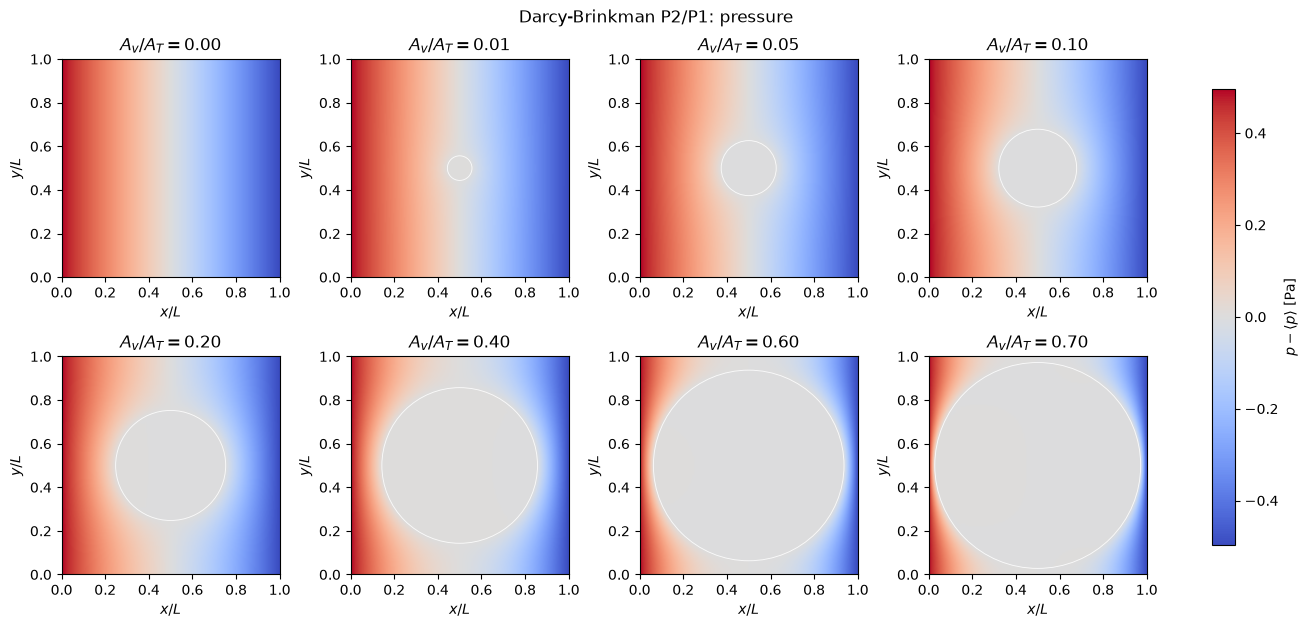

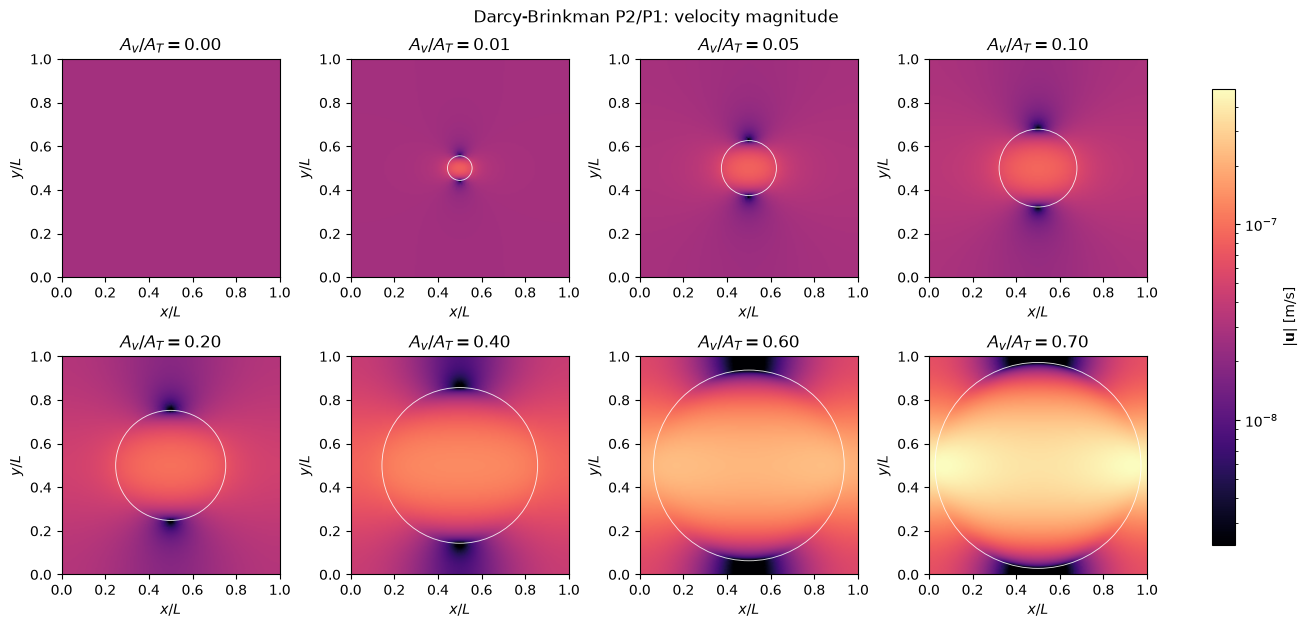

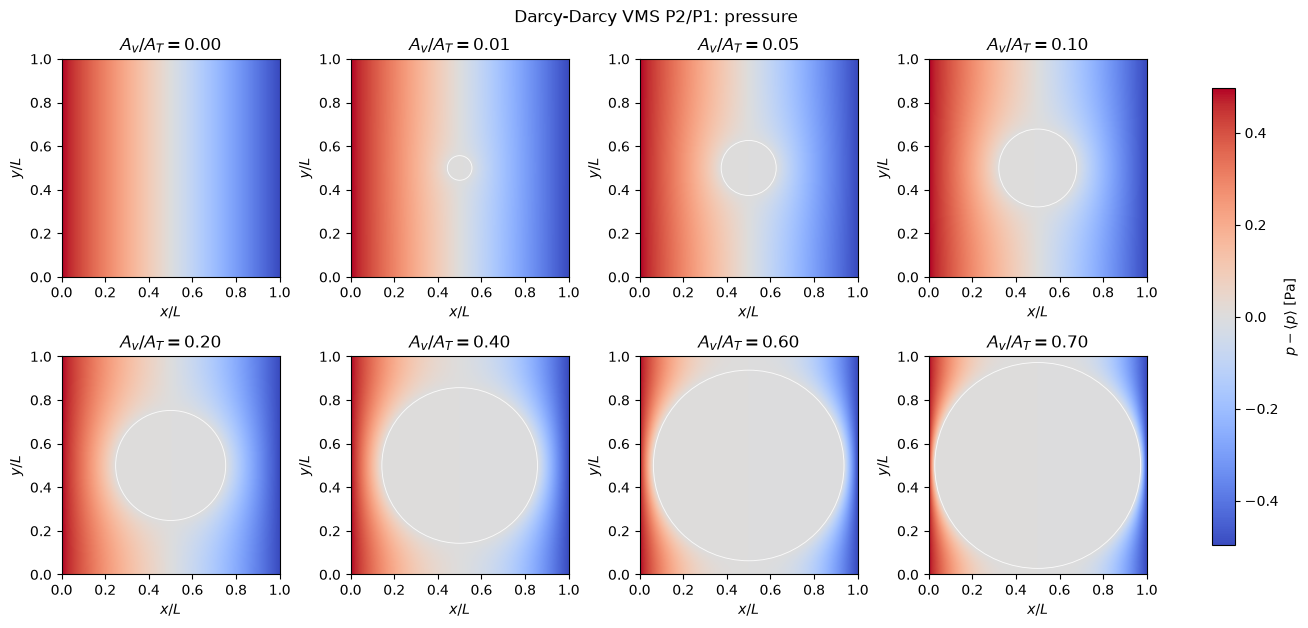

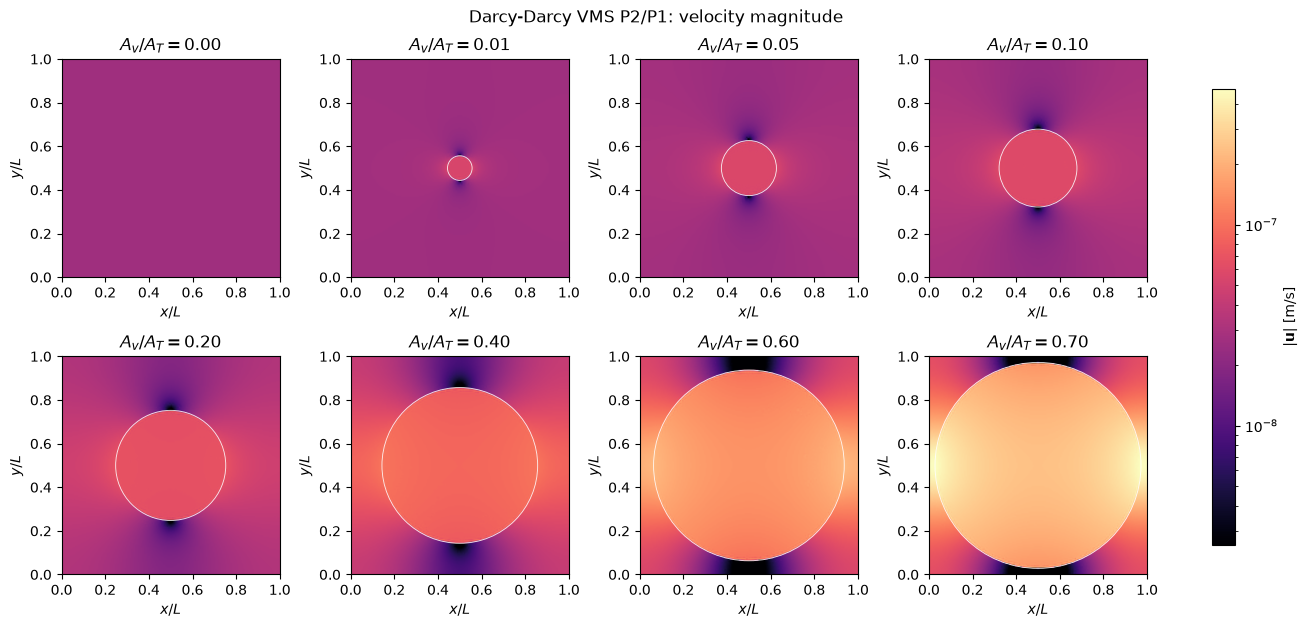

In [9]:
def plot_field_gallery(model: str, field: str, *, cmap: str):
    arrays = [
        np.asarray(sampled_fields[(model, case.area_fraction)][field], dtype=float)
        for case in cases
    ]
    finite = np.concatenate([array[np.isfinite(array)] for array in arrays])
    if field == "velocity_magnitude":
        positive = finite[finite > 0.0]
        norm = LogNorm(
            vmin=max(float(np.percentile(positive, 0.5)), np.finfo(float).tiny),
            vmax=float(np.max(positive)),
        )
        colorbar_label = r"$|\mathbf{u}|$ [m/s]"
    else:
        limit = float(np.max(np.abs(finite)))
        norm = Normalize(vmin=-limit, vmax=limit)
        colorbar_label = r"$p-\langle p\rangle$ [Pa]"

    fig, axes = plt.subplots(2, 4, figsize=(13, 6.2), constrained_layout=True)
    image = None
    for axis, case, array in zip(axes.flat, cases, arrays, strict=True):
        image = axis.imshow(
            array.T,
            origin="lower",
            extent=(0.0, 1.0, 0.0, 1.0),
            cmap=cmap,
            norm=norm,
            interpolation="bilinear",
        )
        if case.radius_fraction > 0.0:
            axis.add_patch(
                Circle(
                    (0.5, 0.5),
                    case.radius_fraction,
                    fill=False,
                    edgecolor="white",
                    linewidth=0.65,
                    alpha=0.85,
                )
            )
        axis.set(
            aspect="equal",
            title=rf"$A_v/A_T={case.area_fraction:.2f}$",
            xlabel=r"$x/L$",
            ylabel=r"$y/L$",
        )
    assert image is not None
    fig.colorbar(image, ax=axes, shrink=0.82, label=colorbar_label)
    field_label = "velocity magnitude" if field == "velocity_magnitude" else "pressure"
    fig.suptitle(f"{model_labels[model]}: {field_label}")
    return fig


gallery_paths = []
for model in models:
    for field, cmap in (
        ("pressure", "coolwarm"),
        ("velocity_magnitude", "magma"),
    ):
        fig = plot_field_gallery(model, field, cmap=cmap)
        path = output_dir / f"{model}_{field}_gallery.png"
        fig.savefig(path, dpi=180)
        gallery_paths.append(path)
        display(fig)
        plt.close(fig)

Each individual case also gets a two-panel diagnostic with pressure and
velocity magnitude plus direction arrows. All 16 figures are displayed below
and saved as standalone PNG files.

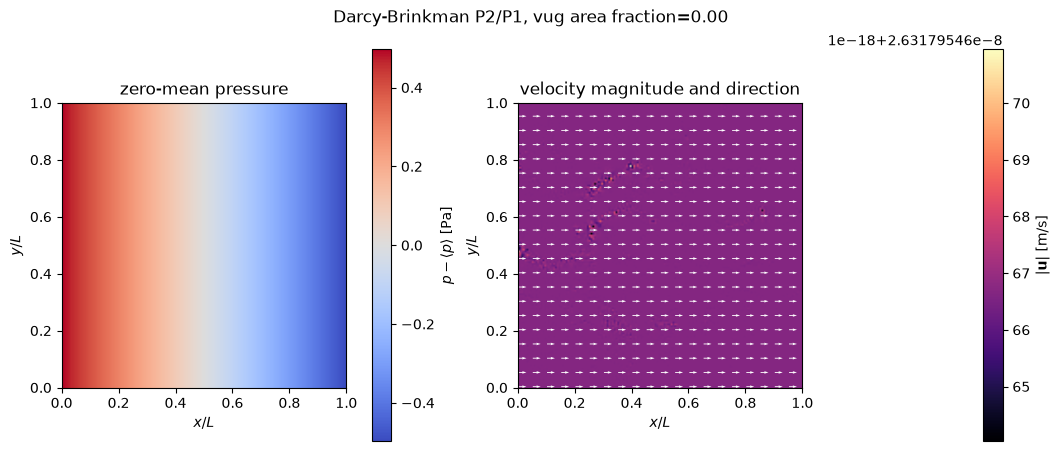

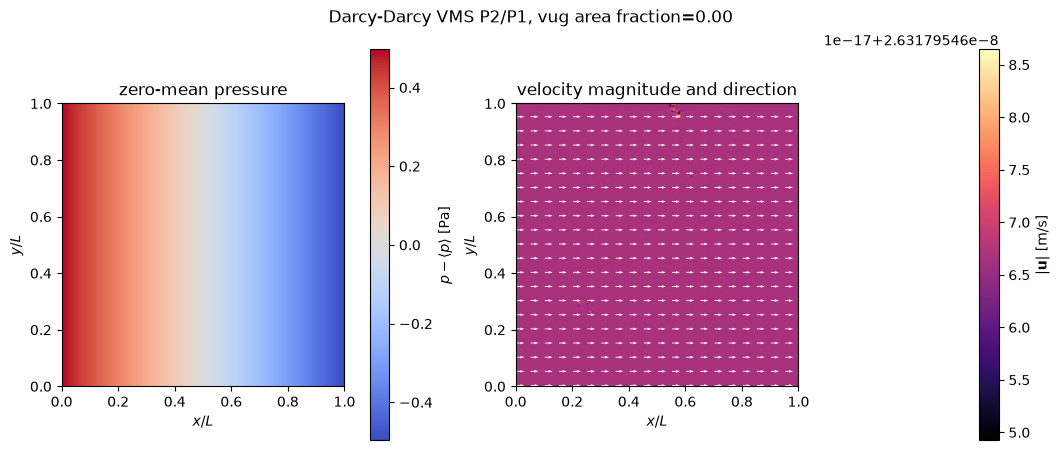

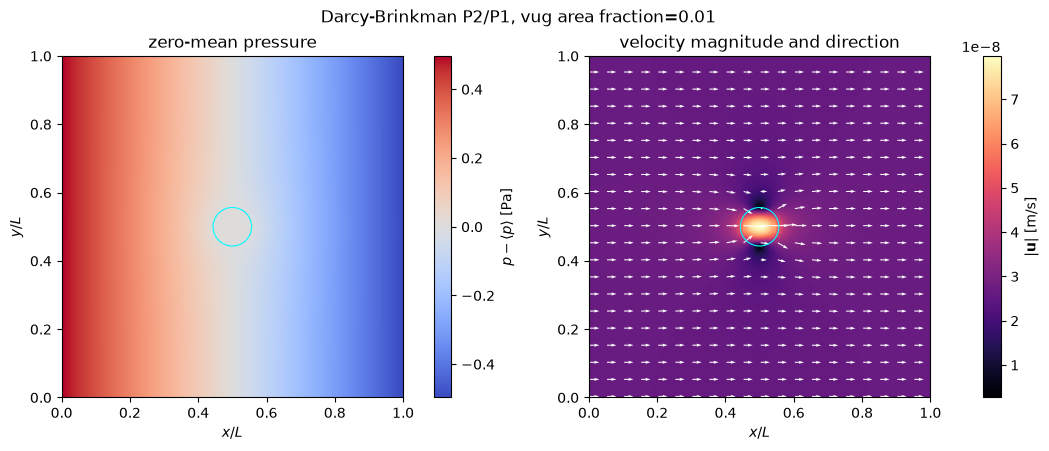

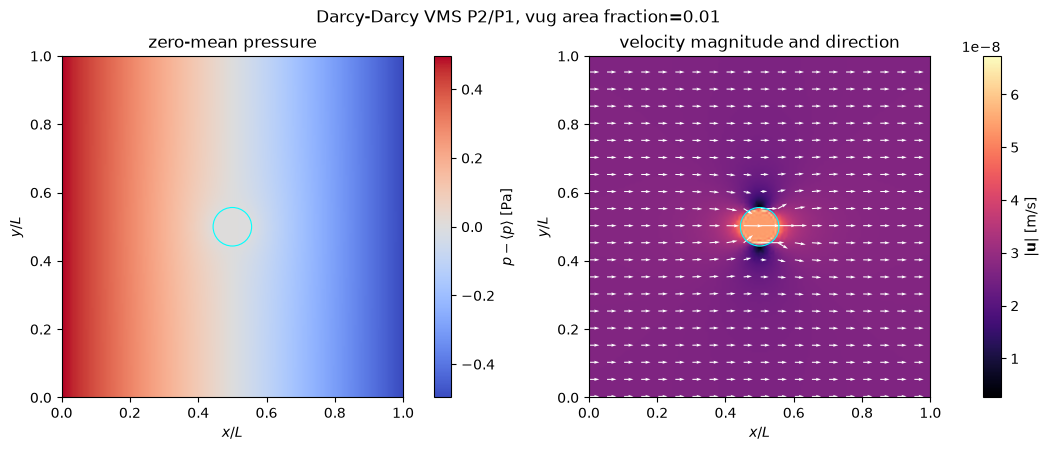

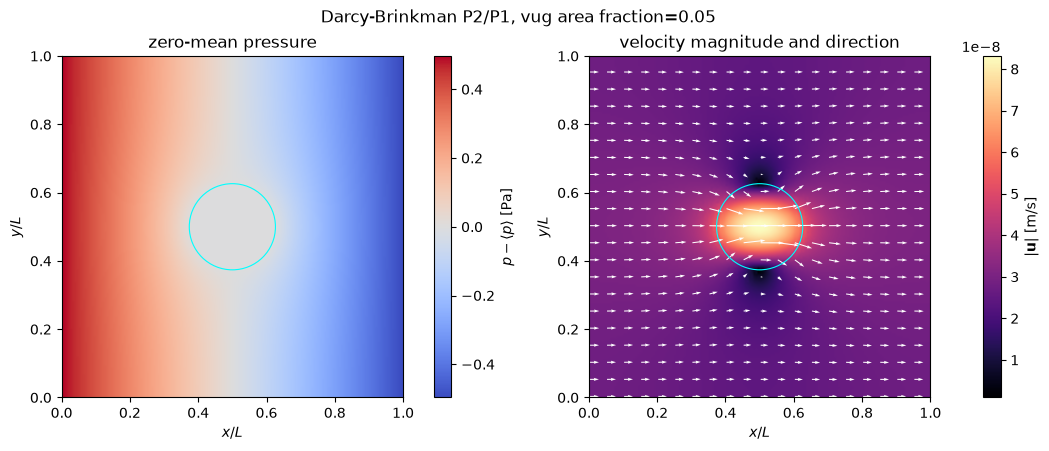

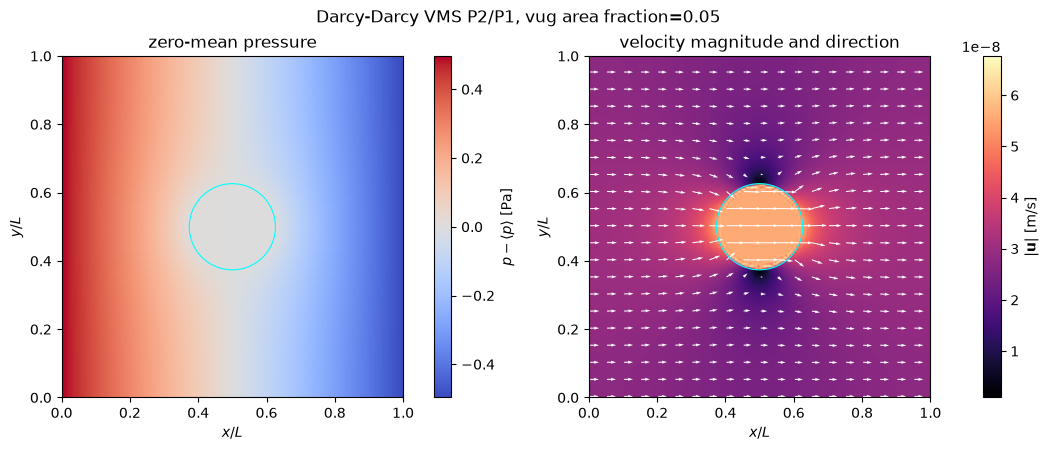

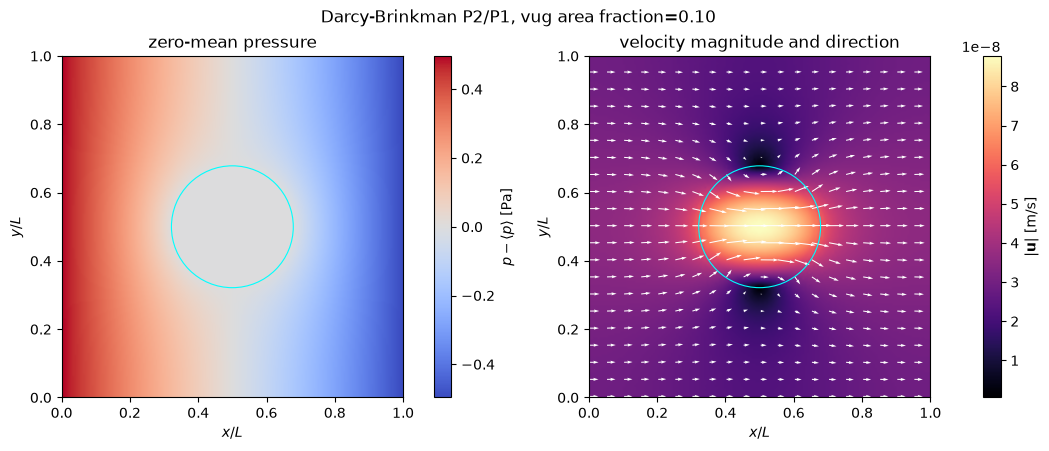

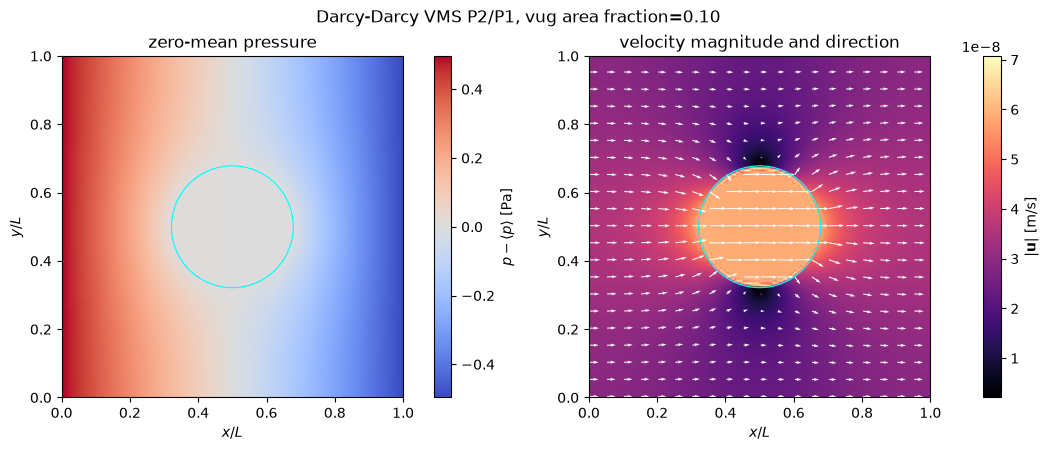

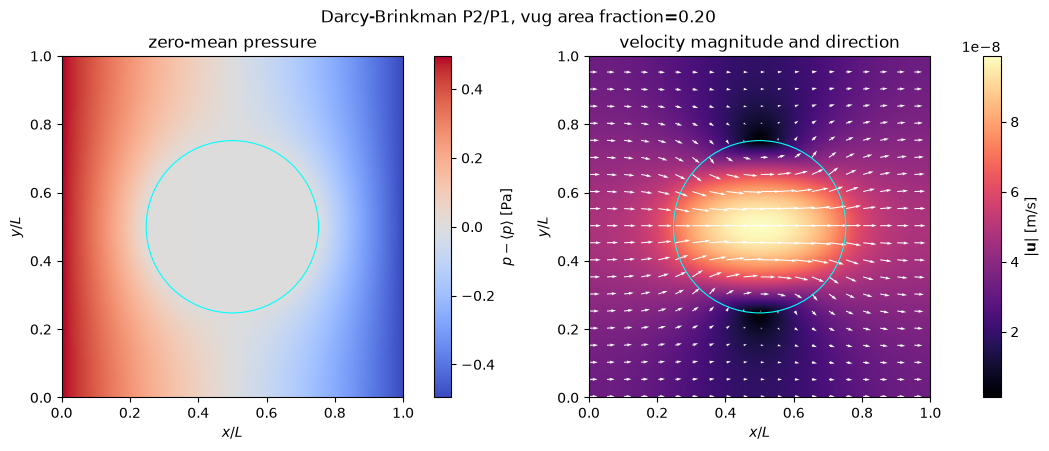

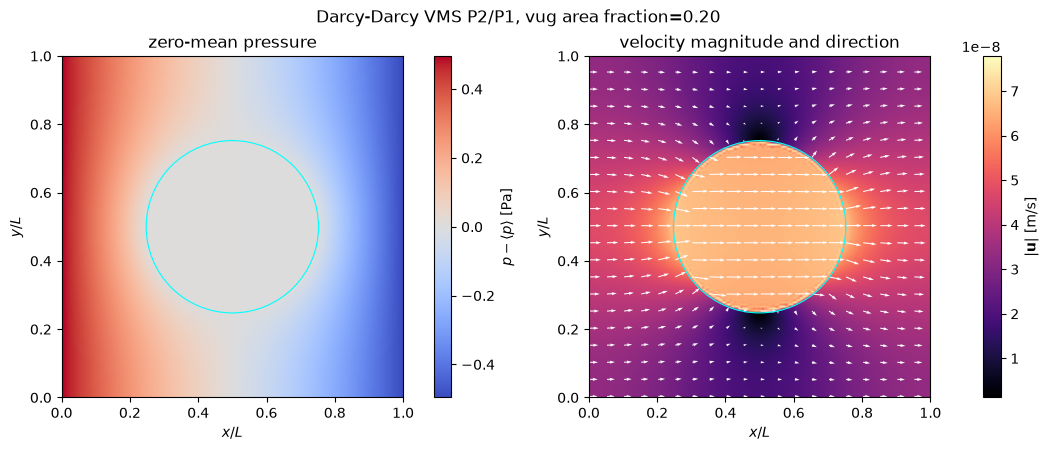

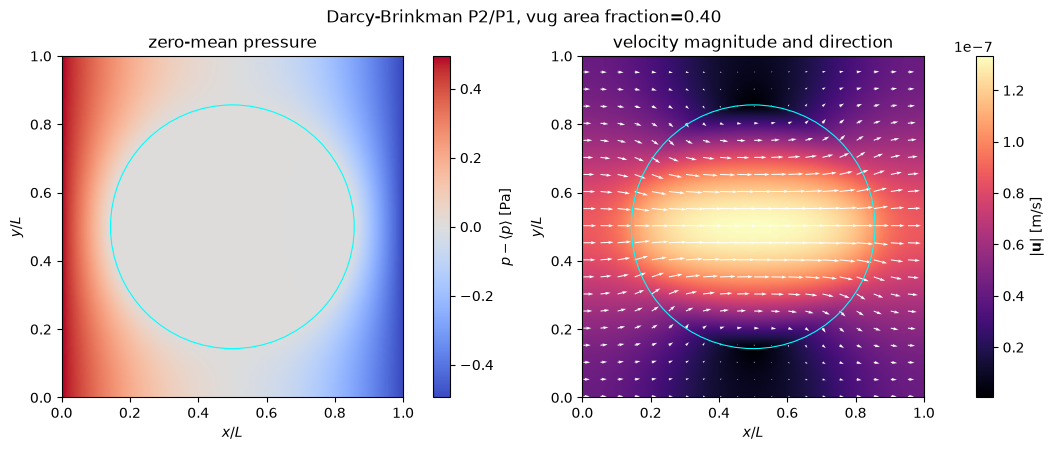

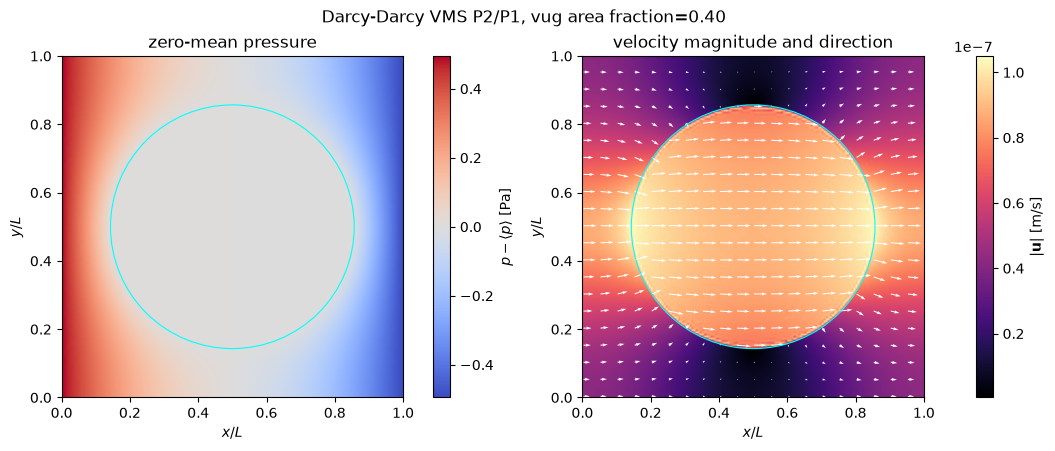

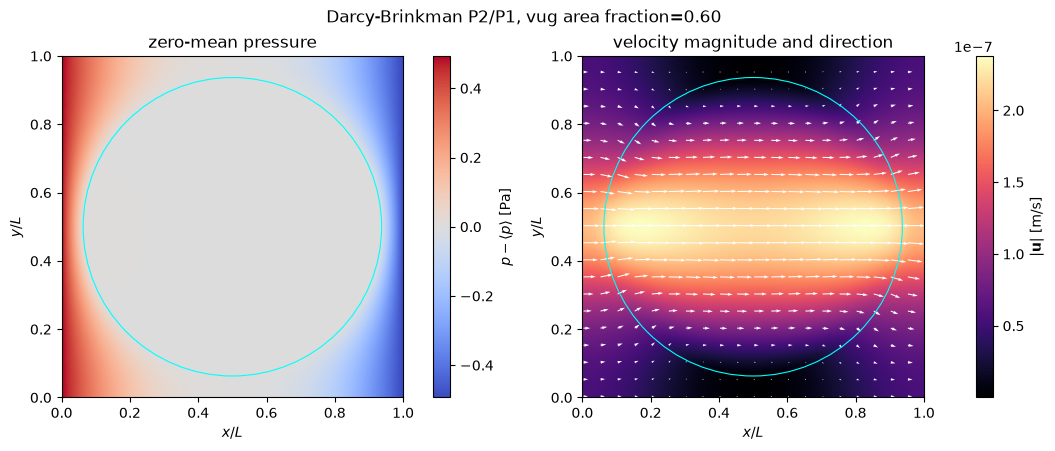

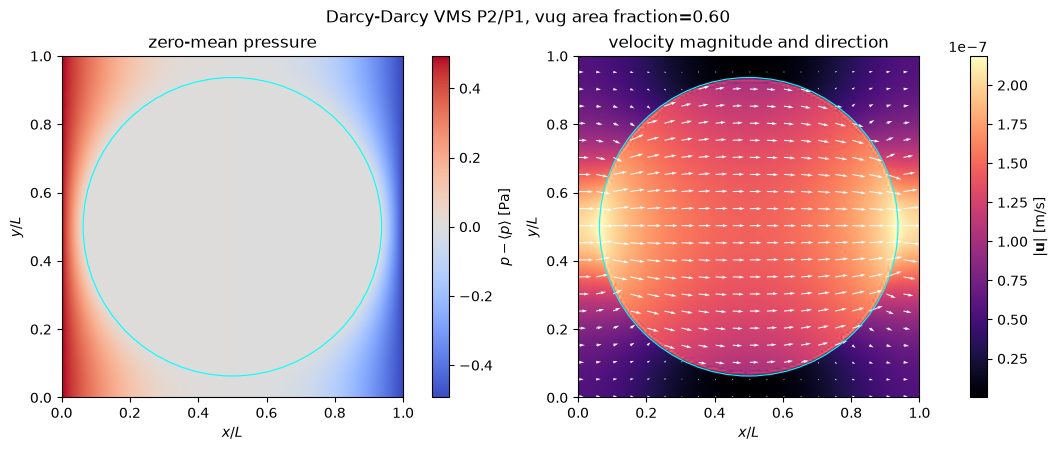

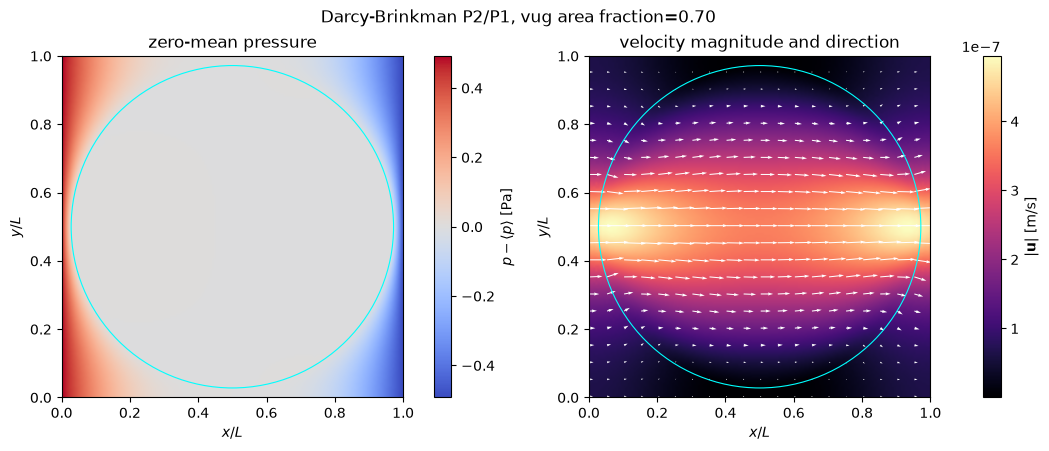

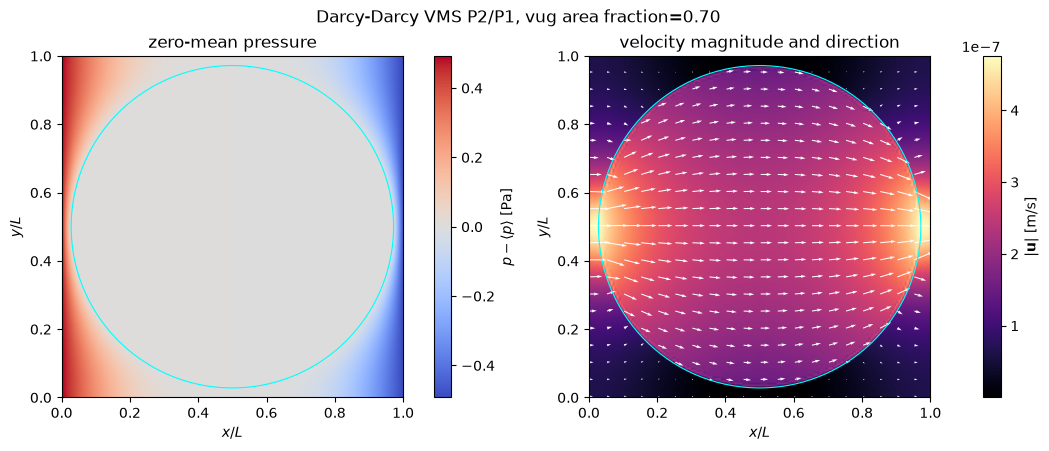

Saved 16 individual field figures.


In [10]:
def plot_case_fields(model: str, case: CenteredVugFlowCase2D):
    fields = sampled_fields[(model, case.area_fraction)]
    pressure = fields["pressure"]
    velocity = fields["velocity"]
    velocity_magnitude = fields["velocity_magnitude"]
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4), constrained_layout=True)

    pressure_limit = float(np.max(np.abs(pressure)))
    pressure_image = axes[0].imshow(
        pressure.T,
        origin="lower",
        extent=(0.0, 1.0, 0.0, 1.0),
        cmap="coolwarm",
        vmin=-pressure_limit,
        vmax=pressure_limit,
        interpolation="bilinear",
    )
    fig.colorbar(pressure_image, ax=axes[0], label=r"$p-\langle p\rangle$ [Pa]")

    velocity_magnitude_image = axes[1].imshow(
        velocity_magnitude.T,
        origin="lower",
        extent=(0.0, 1.0, 0.0, 1.0),
        cmap="magma",
        interpolation="bilinear",
    )
    stride = max(1, plot_sample_resolution // 20)
    points = (np.arange(plot_sample_resolution) + 0.5) / plot_sample_resolution
    grid_x, grid_y = np.meshgrid(points, points, indexing="ij")
    axes[1].quiver(
        grid_x[::stride, ::stride],
        grid_y[::stride, ::stride],
        velocity[0, ::stride, ::stride],
        velocity[1, ::stride, ::stride],
        color="white",
        angles="xy",
        scale_units="xy",
        scale=None,
        width=0.003,
    )
    fig.colorbar(
        velocity_magnitude_image,
        ax=axes[1],
        label=r"$|\mathbf{u}|$ [m/s]",
    )

    for axis in axes:
        if case.radius_fraction > 0.0:
            axis.add_patch(
                Circle(
                    (0.5, 0.5),
                    case.radius_fraction,
                    fill=False,
                    edgecolor="cyan",
                    linewidth=0.8,
                )
            )
        axis.set(aspect="equal", xlabel=r"$x/L$", ylabel=r"$y/L$")
    axes[0].set_title("zero-mean pressure")
    axes[1].set_title("velocity magnitude and direction")
    fig.suptitle(f"{model_labels[model]}, vug area fraction={case.area_fraction:.2f}")
    return fig


individual_field_paths = []
for case in cases:
    for model in models:
        fig = plot_case_fields(model, case)
        fraction_tag = f"{case.area_fraction:.2f}".replace(".", "p")
        path = field_figure_dir / f"{model}_vug_fraction_{fraction_tag}.png"
        fig.savefig(path, dpi=180)
        individual_field_paths.append(path)
        display(fig)
        plt.close(fig)

print(f"Saved {len(individual_field_paths)} individual field figures.")

## 10. Horizontal centerline profiles at $y=L_y/2$

The following plots evaluate the original FEM functions at 401 points on the
exact line $y/L=0.5$. They are not extracted from a neighboring raster row.
Pressure, axial velocity $u_x$, and transverse velocity $u_y$ are displayed
in separate figures for each model. Every line corresponds to one vug area
fraction.

Because the geometry and loading are symmetric about this line, $u_y$ should
be zero up to discretization and linear-solver error. Its separate plot is
therefore also a useful symmetry diagnostic.

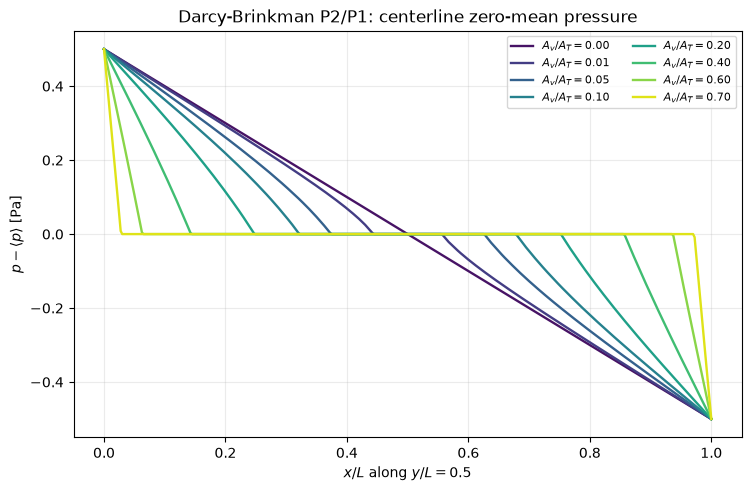

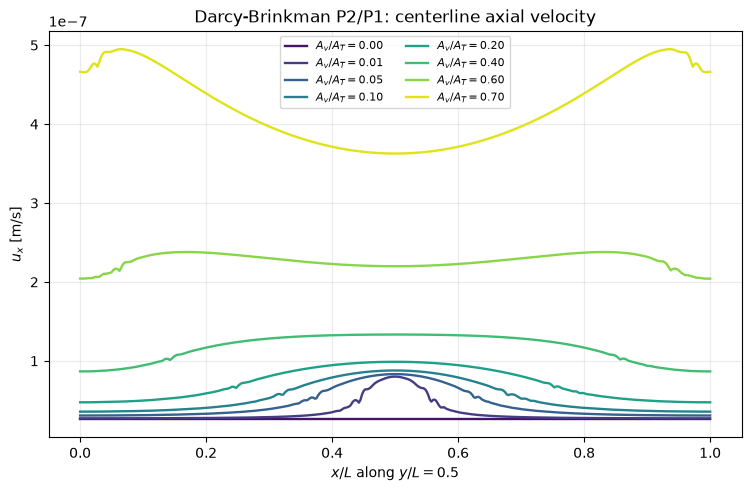

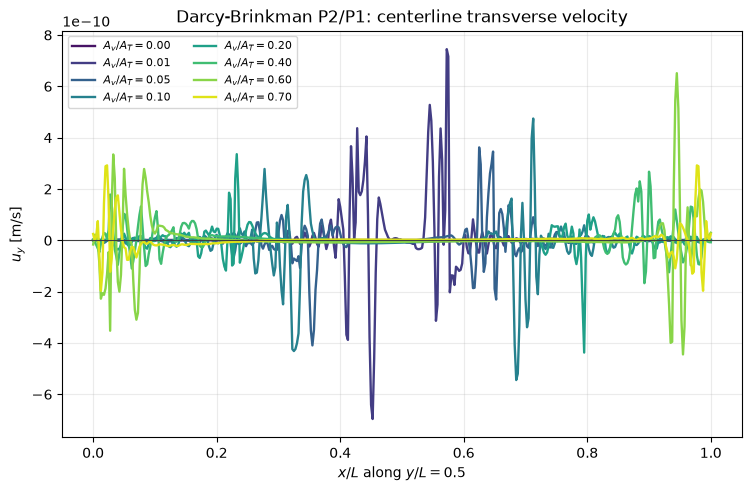

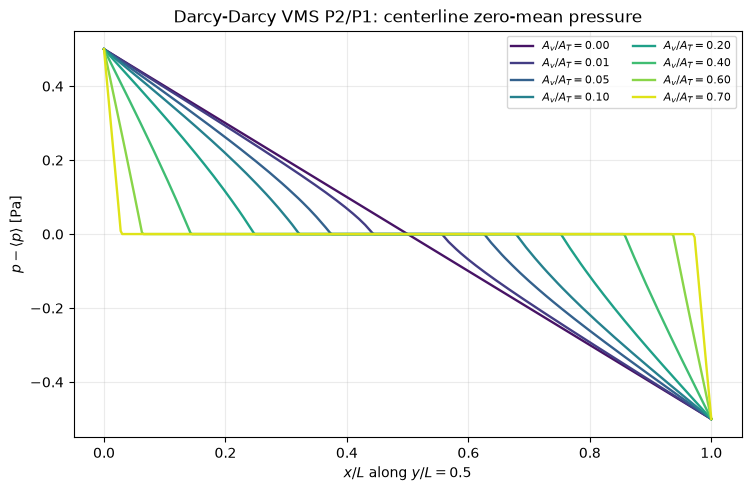

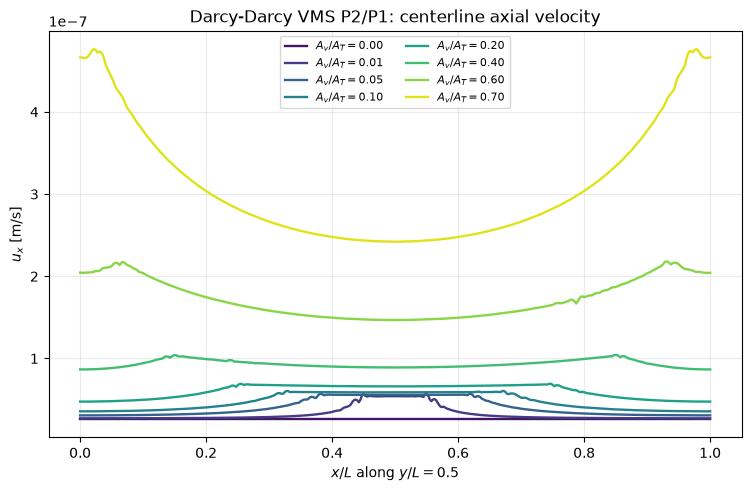

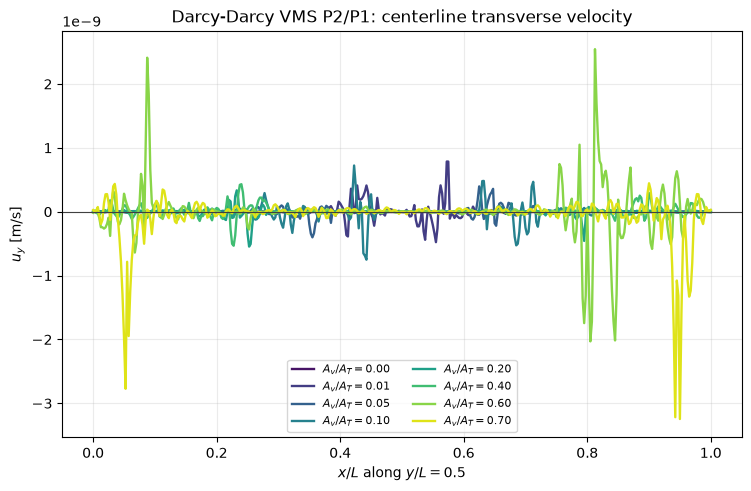

Maximum centerline |uy|/maximum centerline |ux|: 6.558e-03
Centerline profile CSV: /Users/dtvolpatto/Work/voids/notebooks/outputs/53_mwe_body_fitted_2d_centered_vug_upscaling/centerline_profiles_y_over_L_0p5.csv


In [11]:
centerline_plot_specs = (
    (
        "pressure",
        r"$p-\langle p\rangle$ [Pa]",
        "zero-mean pressure",
    ),
    (
        "velocity_x",
        r"$u_x$ [m/s]",
        "axial velocity",
    ),
    (
        "velocity_y",
        r"$u_y$ [m/s]",
        "transverse velocity",
    ),
)
centerline_colors = plt.get_cmap("viridis")(np.linspace(0.05, 0.95, len(cases)))
centerline_figure_paths = []

for model in models:
    for field_key, ylabel, field_title in centerline_plot_specs:
        fig, axis = plt.subplots(figsize=(7.4, 4.8), constrained_layout=True)
        for case, color in zip(cases, centerline_colors, strict=True):
            axis.plot(
                centerline_x_over_L,
                centerline_fields[(model, case.area_fraction)][field_key],
                color=color,
                linewidth=1.7,
                label=rf"$A_v/A_T={case.area_fraction:.2f}$",
            )
        if field_key == "velocity_y":
            axis.axhline(0.0, color="0.25", linewidth=0.8)
        axis.set(
            xlabel=r"$x/L$ along $y/L=0.5$",
            ylabel=ylabel,
            title=f"{model_labels[model]}: centerline {field_title}",
        )
        axis.grid(alpha=0.25)
        axis.legend(ncol=2, fontsize=8)
        if field_key.startswith("velocity"):
            axis.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
        path = output_dir / f"{model}_centerline_{field_key}.png"
        fig.savefig(path, dpi=190)
        centerline_figure_paths.append(path)
        display(fig)
        plt.close(fig)

maximum_centerline_ux = max(
    float(np.max(np.abs(fields["velocity_x"]))) for fields in centerline_fields.values()
)
maximum_centerline_uy = max(
    float(np.max(np.abs(fields["velocity_y"]))) for fields in centerline_fields.values()
)
print(
    "Maximum centerline |uy|/maximum centerline |ux|:",
    f"{maximum_centerline_uy / maximum_centerline_ux:.3e}",
)
print("Centerline profile CSV:", centerline_profiles_path)

A nonzero $u_y$ on this symmetry line is a numerical symmetry defect caused
by the unstructured mesh, discrete solve, and point evaluation; it is not
physical transverse flow for the centered geometry. The ratio printed above
quantifies its size relative to the largest sampled $|u_x|$. A symmetry-
constrained mesh or further refinement can reduce it.

## 11. Compare effective permeability

Both curves use the same geometry, $K_m$, pressure drop, and P2/P1 polynomial degrees.
Their vug constitutive treatments intentionally differ: Darcy--Brinkman has
$\gamma_B=0$, whereas Darcy--Darcy uses $\gamma_D=\mu/K_v$ with the
configured finite $K_v$.

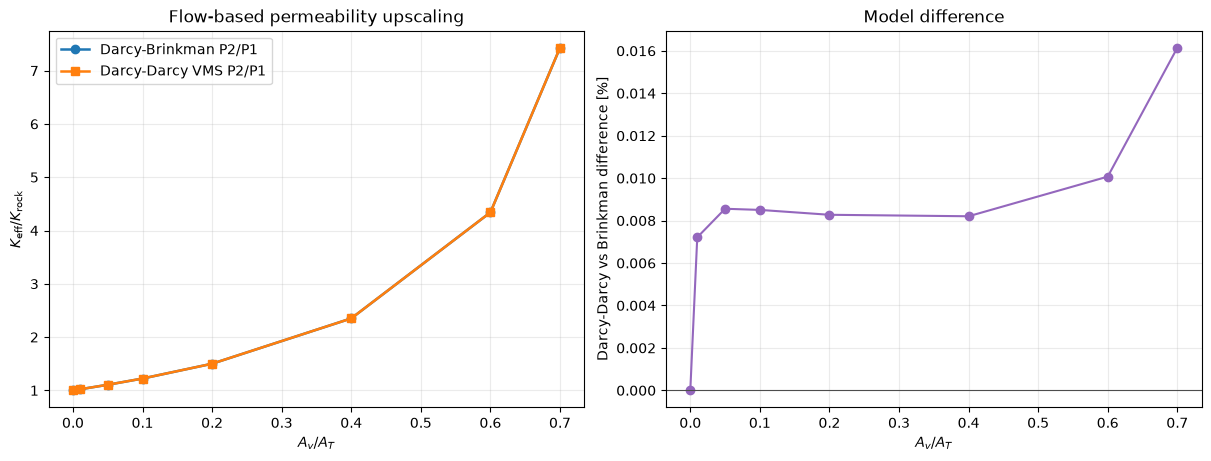

model,darcy_brinkman,darcy_darcy
vug_area_fraction_requested,,
0.00,1.000000,1.000000
0.01,1.020055,1.020129
0.05,1.105074,1.105168
0.10,1.222004,1.222108
0.20,1.500011,1.500135
0.40,2.350434,2.350626
0.60,4.340181,4.340618
0.70,7.427647,7.428846


Maximum Darcy-Darcy vs Darcy-Brinkman difference: 0.0161%


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
wide = summary.pivot(
    index="vug_area_fraction_requested",
    columns="model",
    values="Keff_over_Krock",
).sort_index()

for model, marker in zip(models, ("o", "s"), strict=True):
    axes[0].plot(
        wide.index,
        wide[model],
        marker=marker,
        linewidth=1.8,
        label=model_labels[model],
    )
axes[0].set(
    xlabel=r"$A_v/A_T$",
    ylabel=r"$K_\mathrm{eff}/K_\mathrm{rock}$",
    title="Flow-based permeability upscaling",
)
axes[0].grid(alpha=0.25)
axes[0].legend()

relative_difference_percent = (
    100.0 * (wide["darcy_darcy"] - wide["darcy_brinkman"]) / wide["darcy_brinkman"]
)
axes[1].plot(wide.index, relative_difference_percent, "o-", color="tab:purple")
axes[1].axhline(0.0, color="0.3", linewidth=0.8)
axes[1].set(
    xlabel=r"$A_v/A_T$",
    ylabel="Darcy-Darcy vs Brinkman difference [%]",
    title="Model difference",
)
axes[1].grid(alpha=0.25)

comparison_figure_path = output_dir / "effective_permeability_model_comparison.png"
fig.savefig(comparison_figure_path, dpi=200)
display(fig)
plt.close(fig)

display(wide)
print(
    "Maximum Darcy-Darcy vs Darcy-Brinkman difference:",
    f"{float(np.max(np.abs(relative_difference_percent))):.4f}%",
)

## 12. Is the nominal 100×100 mesh fine enough for this reported curve?

We rerun the most demanding $f_v=0.70$ geometry at nominal resolutions
50, 75, and 100. The 100-level results above are reused.

This checks the integral output $K_\mathrm{eff}$, not pointwise resolution
of the thin Brinkman interface layer. Here
$\sqrt{K_m/\phi_m}\approx1\,\mu\mathrm{m}$, while the nominal 100-level
element diameter is about $106\,\mu\mathrm{m}$. The requested near-regular
mesh therefore cannot be called interface-layer DNS even if its upscaled
permeability is mesh-stable.

Info    : Clearing all models and views...
Info    : Done clearing all models and views


Info    : Clearing all models and views...
Info    : Done clearing all models and views


Info    : Clearing all models and views...
Info    : Done clearing all models and views


Info    : Clearing all models and views...
Info    : Done clearing all models and views


,model,mesh_resolution,num_triangles,Keff_over_Krock,relative_change_from_previous
0,darcy_brinkman,50,3016,7.414880,NaN
2,darcy_brinkman,75,6730,7.424201,0.001257
4,darcy_brinkman,100,11820,7.427647,0.000464
1,darcy_darcy,50,3016,7.422111,NaN
3,darcy_darcy,75,6730,7.427224,0.000689
5,darcy_darcy,100,11820,7.428846,0.000218


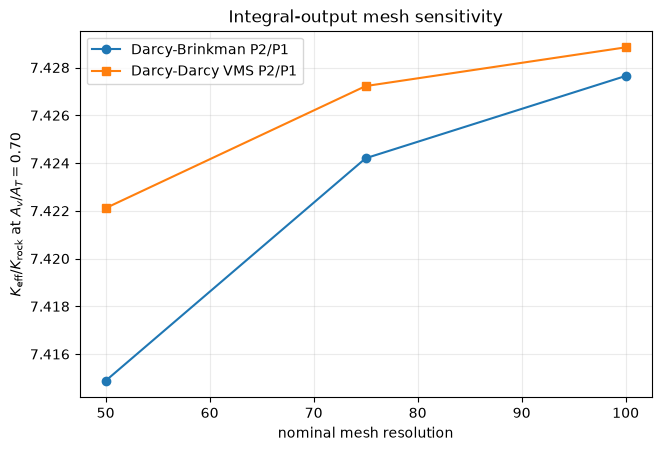

In [13]:
sensitivity_rows = []
finest_case = cases[-1]
for resolution in (50, 75):
    sensitivity_case = replace(finest_case, mesh_resolution=resolution)
    for model in models:
        sensitivity_result = run_centered_vug_flow_case(
            sensitivity_case,
            model=model,
            options=solver_options,
            vms_constant=vms_constant,
        )
        sensitivity_rows.append(
            {
                "model": model,
                "mesh_resolution": resolution,
                "num_triangles": sensitivity_result.metadata["num_cells"],
                "Keff_over_Krock": (
                    sensitivity_result.permeability
                    / sensitivity_case.matrix_permeability_m2
                ),
            }
        )
for model in models:
    finest_result = results[(model, finest_case.area_fraction)]
    sensitivity_rows.append(
        {
            "model": model,
            "mesh_resolution": mesh_resolution,
            "num_triangles": finest_result.metadata["num_cells"],
            "Keff_over_Krock": (
                finest_result.permeability / finest_case.matrix_permeability_m2
            ),
        }
    )

sensitivity = pd.DataFrame(sensitivity_rows).sort_values(["model", "mesh_resolution"])
sensitivity["relative_change_from_previous"] = sensitivity.groupby("model")[
    "Keff_over_Krock"
].pct_change()
display(sensitivity)

for model in models:
    model_rows = sensitivity[sensitivity["model"] == model]
    final_change = float(model_rows.iloc[-1]["relative_change_from_previous"])
    assert abs(final_change) < 0.01

fig, axis = plt.subplots(figsize=(6.5, 4.4), constrained_layout=True)
for model, marker in zip(models, ("o", "s"), strict=True):
    model_rows = sensitivity[sensitivity["model"] == model]
    axis.plot(
        model_rows["mesh_resolution"],
        model_rows["Keff_over_Krock"],
        marker=marker,
        label=model_labels[model],
    )
axis.set(
    xlabel="nominal mesh resolution",
    ylabel=r"$K_\mathrm{eff}/K_\mathrm{rock}$ at $A_v/A_T=0.70$",
    title="Integral-output mesh sensitivity",
)
axis.grid(alpha=0.25)
axis.legend()
sensitivity_figure_path = output_dir / "mesh_sensitivity_fraction_0p70.png"
fig.savefig(sensitivity_figure_path, dpi=180)
display(fig)
plt.close(fig)

## 13. Open the results in ParaView

The exported mesh coordinates are normalized $(x/L,y/L)$, while pressure and
velocity values are in Pa and m/s. To display physical coordinates in meters,
apply a ParaView **Transform** with scale $(L,L,1)=(0.0075,0.0075,1)$ for the
default configuration.

For each model and area fraction:

1. open the corresponding `.xdmf` file under `paraview/`;
2. click **Apply**;
3. choose `pressure` or `velocity` in the coloring menu;
4. use **Glyph** for arrows or **Calculator** with `mag(velocity)` for
   velocity magnitude;
5. keep each `.h5` file beside its `.xdmf` file.

The CSV table records every export path. The following manifest makes the
configuration and the visualization interpolation explicit.

In [14]:
configuration = {
    "image_shape": image_shape,
    "voxel_size_um": voxel_size_um,
    "side_length_mm": 1.0e3 * cases[0].side_length_m,
    "matrix_porosity": matrix_porosity,
    "matrix_permeability_md": matrix_permeability_md,
    "darcy_brinkman_vug_drag_pa_s_per_m2": 0.0,
    "darcy_darcy_vug_permeability_m2": darcy_darcy_vug_permeability_m2,
    "dynamic_viscosity_pa_s": dynamic_viscosity_pa_s,
    "pressure_inlet_pa": pressure_inlet_pa,
    "pressure_outlet_pa": pressure_outlet_pa,
    "vug_area_fractions": list(vug_area_fractions),
    "mesh_resolution": mesh_resolution,
    "centerline_sample_count": centerline_sample_count,
    "centerline_definition": "exact FEM evaluation at y/L=0.5",
    "mesh_size_policy": "nearly_uniform_body_fitted",
    "finite_element_pair": "Taylor-Hood CG2 velocity x CG1 pressure",
    "darcy_stabilization": "residual-based VMS stabilization, C_M=1",
    "paraview_export": "CG1 visualization copies of the solved P2/P1 fields",
    "scientific_caveat": (
        "effective-permeability mesh sensitivity passed; the approximately "
        "1 um Brinkman screening layer is not pointwise resolved by the "
        "requested near-regular 100x100 mesh"
    ),
}
configuration_path = output_dir / "configuration.json"
configuration_path.write_text(
    json.dumps(configuration, indent=2) + "\n", encoding="utf-8"
)

display(
    summary[
        [
            "model",
            "vug_area_fraction_requested",
            "Keff_over_Krock",
            "xdmf",
        ]
    ]
)
print("Configuration:", configuration_path)
print("Summary CSV:", summary_path)

,model,vug_area_fraction_requested,Keff_over_Krock,xdmf
0,darcy_brinkman,0.00,1.000000,notebooks/outputs/53_mwe_body_fitted_2d_center...
1,darcy_darcy,0.00,1.000000,notebooks/outputs/53_mwe_body_fitted_2d_center...
2,darcy_brinkman,0.01,1.020055,notebooks/outputs/53_mwe_body_fitted_2d_center...
3,darcy_darcy,0.01,1.020129,notebooks/outputs/53_mwe_body_fitted_2d_center...
4,darcy_brinkman,0.05,1.105074,notebooks/outputs/53_mwe_body_fitted_2d_center...
5,darcy_darcy,0.05,1.105168,notebooks/outputs/53_mwe_body_fitted_2d_center...
6,darcy_brinkman,0.10,1.222004,notebooks/outputs/53_mwe_body_fitted_2d_center...
7,darcy_darcy,0.10,1.222108,notebooks/outputs/53_mwe_body_fitted_2d_center...
8,darcy_brinkman,0.20,1.500011,notebooks/outputs/53_mwe_body_fitted_2d_center...
9,darcy_darcy,0.20,1.500135,notebooks/outputs/53_mwe_body_fitted_2d_center...


Configuration: /Users/dtvolpatto/Work/voids/notebooks/outputs/53_mwe_body_fitted_2d_centered_vug_upscaling/configuration.json
Summary CSV: /Users/dtvolpatto/Work/voids/notebooks/outputs/53_mwe_body_fitted_2d_centered_vug_upscaling/centered_vug_upscaling_summary.csv


## 14. Common mistakes and interpretation limits

- **Calling the matrix solid and then setting $\phi_m=0.2$:** here “matrix”
  means the porous rock continuum. It carries Darcy flow.
- **Treating $f_v$ as total porosity:** use
  $f_v+(1-f_v)\phi_m$ only as a geometric bulk estimate.
- **Applying $K_v=10^{-8}\,\mathrm{m}^2$ to both methods:** it is a finite
  Darcy--Darcy closure only. Darcy--Brinkman uses $\gamma_B=0$ in the vug.
- **Calling the Darcy--Darcy $K_v$ a measured vug property:** it is a finite
  numerical/continuum surrogate for an open region.
- **Assuming the 500² pixels are FEM elements:** physical size comes from the
  image metadata, but the body-fitted continuum mesh is independent.
- **Claiming pointwise interface convergence from a permeability curve:** the
  mesh-sensitivity check above covers the integral output only.
- **Comparing Darcy--Darcy curves with different $K_v$, length, or boundary
  conditions:** those changes alter the physical problem, not just the
  discretization.
- **Interpreting agreement between Darcy--Darcy and Darcy--Brinkman as proof:**
  agreement here reflects this high-contrast, coarse-interface upscaling
  regime; it does not establish equivalence for other Darcy numbers.

## 15. What was produced?

- 16 solved P2/P1 configurations;
- 16 ParaView XDMF/HDF5 pairs;
- pressure and velocity-magnitude galleries for both models;
- 16 individual pressure/velocity figures;
- six exact $y/L=0.5$ pressure, $u_x$, and $u_y$ profile figures;
- a CSV table containing every centerline sample;
- normalized effective-permeability and model-difference curves;
- a 50/75/100 mesh-sensitivity table and plot;
- CSV and JSON provenance files.

The reusable geometry, nondimensionalization, forms, solve, SI conversion, and
export logic live in `voids`; the notebook only orchestrates and explains the
study.

In [15]:
produced = {
    "configuration": configuration_path,
    "summary": summary_path,
    "centerline_profiles": centerline_profiles_path,
    "geometry_figure": geometry_figure_path,
    "mesh_figure": mesh_figure_path,
    "comparison_figure": comparison_figure_path,
    "sensitivity_figure": sensitivity_figure_path,
    "gallery_figures": gallery_paths,
    "individual_field_figures": individual_field_paths,
    "centerline_figures": centerline_figure_paths,
    "paraview_xdmf_files": sorted(paraview_dir.glob("*.xdmf")),
}
pd.DataFrame(
    [
        {"artifact": name, "count": len(value) if isinstance(value, list) else 1}
        for name, value in produced.items()
    ]
)

,artifact,count
0,configuration,1
1,summary,1
2,centerline_profiles,1
3,geometry_figure,1
4,mesh_figure,1
5,comparison_figure,1
6,sensitivity_figure,1
7,gallery_figures,4
8,individual_field_figures,16
9,centerline_figures,6
